# Feature Extraction and Price Prediction for Mobile Phones

## Introduction

The smartphone market is highly competitive, with manufacturers continuously introducing devices that differ in performance, design, and technological capabilities. Features such as RAM, storage capacity, processor type, battery capacity, and camera specifications significantly influence how smartphones are positioned and priced in the market.

For organizations involved in selling mobile phones, understanding how these technical specifications influence pricing is critical. Accurate price estimation can help businesses design effective pricing strategies, optimize product positioning, and better understand which features contribute the most to the perceived value of a device.

In this project, a dataset containing specifications of various mobile phones is analyzed to identify the key features that influence smartphone prices. The primary objective is to develop a machine learning model capable of predicting the price of a mobile phone based on its specifications.

To achieve this objective, the project follows a structured data science workflow. The dataset is first explored and cleaned to ensure data quality. Exploratory Data Analysis (EDA) is then conducted to understand feature distributions and relationships with price. Feature engineering techniques are applied to create meaningful predictors that better represent device capabilities.

Subsequently, multiple machine learning models are trained and evaluated to predict mobile phone prices. Feature importance analysis is performed to identify which specifications have the strongest influence on pricing.

The insights derived from this analysis can help organizations better understand pricing dynamics in the smartphone market an


## STEP 1: Importing Libraries


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap

import warnings
warnings.filterwarnings("ignore")


## STEP 2: LOAD THE DATASET (Processed_Flipdata.xlsx)


In [2]:
df = pd.read_excel("Processed_FlipData.xlsx")

df.head(5)

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,11999
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,5649
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,8999



This dataset contains mobile phone features such as:
* RAM
* Storage
* Battery
* Camera
* Processor
* Prize (Target Variable)
* Colour

These features will be used to:
- Analyze pricing patterns
- Train Machine Learning Models
- Predict Mobile phone prices.

## STEP 3: BASIC EXPLORATION

The purpose of basic exploration is to understand the **structure, quality, and statistical properties of the dataset** before performing detailed **EDA & Feature Engineering**

This steps helps identify:
- Data Types
- Missing Values
- Duplicate Values
- Statistical Summary
- Data Consistency

This is a important step in building a **reliable and production ready Machine Learning model.**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 50.8+ KB


In [4]:
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height,Prize
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201,16228.375231
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553,10793.588322
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000,920.000000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000,9290.000000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000,13499.000000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000,19280.000000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000,80999.000000


NOTE : This is important for **pricing strategy and segmentation**

----

In [5]:
df.duplicated().sum()

np.int64(0)

The dataset contains **no duplicate records.** This indicates good data quality and ensures that the model will not be biased due to repeated entries. Therefore, no duplicate removal is required.

----------



In [6]:
df.isnull().sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

NOTE: **Missing value** analysis confirmed that the dataset is clean and suitable for machine learning model development, ensuring reliable and accurate price prediction.

----

## STEP 4: DATA CLEANING


In [7]:
df['Rear Camera'] = df['Rear Camera'].astype(str).str.replace("MP", "", regex=False)
df['Rear Camera'] = pd.to_numeric(df['Rear Camera'], errors='coerce')

df['Front Camera'] = df['Front Camera'].astype(str).str.replace("MP", "", regex=False)
df['Front Camera'] = pd.to_numeric(df['Front Camera'], errors='coerce')

df[['Rear Camera','Front Camera']].head()

,Rear Camera,Front Camera
0,13,5
1,13,5
2,50,16
3,8,5
4,50,5


**NOTE**: Text values such as "MP" were removed from camera columns and converted into integer format to make the features suitable for Machine Learning model training.

---

**Dropping Unnecessary Columns and Renaming Columns**

In this step, we perform data cleaning and preprocessing by:
- Removing unwanted columns
- Renaming incorrect named columns
- Improving dataset readability & consistency

The above steps are necessary before performing analysis and model building.


In [8]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

rename_dict = {
    'Prize': 'Price',
    'Battery_': 'Battery',
    'Processor_': 'Processor'
}

df.rename(columns = rename_dict, inplace=True)

df.head()

,Model,Colour,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor,Price
0,Infinix SMART 7,Night Black,64,4,6000,13,5,1,16.76,Unisoc Spreadtrum SC9863A1,7299
1,Infinix SMART 7,Azure Blue,64,4,6000,13,5,1,16.76,Unisoc Spreadtrum SC9863A1,7299
2,MOTOROLA G32,Mineral Gray,128,8,5000,50,16,0,16.64,Qualcomm Snapdragon 680,11999
3,POCO C50,Royal Blue,32,2,5000,8,5,0,16.56,Mediatek Helio A22,5649
4,Infinix HOT 30i,Marigold,128,8,5000,50,5,1,16.76,G37,8999


**Explaination:**

**Removing Unwanted Column:** Sometimes when a dataset is saved from Excel or CSV, an extra column called "Unnamed: 0" is created.

We need to remove it as it does not contribute to model learning, it can negatively  affect model performance and it is an unnecessary feature.

**Renaming** is important as some column names are incorrect, mispelled and not professional. This improves readability, makes dataset professional, prevents coding confusion, and helps in better feature engineering.

NOTE: Data cleaning was performed by removing irrelevant columns and correcting column names to improve dataset quality and ensure consistency for accurate model training.

-----

## STEP 5: FEATURE ENGINEERING

**5.1: Feature Engineering from Processor column**

The goal is of this step is to extract the Processor Brand from the Processor Name column and create a new feature called "Processor Brand".

Processor Brand is an important factor that influences mobile price, performance and market position.

In the dataset, the Processor column contains full processor names. Machine Learning model performs better when data is **clean, structured and meaningful.** So we extract only brand name.



In [9]:
def extract_processor_brand(text):
    text = str(text).lower()
    if 'snapdragon' in text:
        return 'Qualcomm'
    elif 'mediatek'in text or 'helio' in text:
        return 'Mediatek'
    elif 'unisoc' in text or 'spreadtrum' in text:
        return 'Unisoc'
    elif 'exynos' in text:
        return 'Exynos'
    else:
        return 'other'

df['Processor_Brand'] = df['Processor'].apply(extract_processor_brand)

df[['Processor', 'Processor_Brand']].head()

,Processor,Processor_Brand
0,Unisoc Spreadtrum SC9863A1,Unisoc
1,Unisoc Spreadtrum SC9863A1,Unisoc
2,Qualcomm Snapdragon 680,Qualcomm
3,Mediatek Helio A22,Mediatek
4,G37,other


**NOTE:** The above steps helps the model better understand processor-level impact on price.

----

**5.2: BRAND(Model) Featuring**

Brand(model) feature is extremely important as it captures - 
* Brand Value
* Premium Positioning
* Customer Trust
* Market Segment

Machine Learning cannot understand this from the Model Name alone. So Brand Name must be extracted.

In [10]:
# Extract Brand from Model Column

df['Brand'] = df['Model'].str.split().str[0]

# Standardized Brand Names (Very Important)

df['Brand'] = df['Brand'].str.upper()

df['Brand'] = df['Brand'].replace({'REDMI':'XIAOMI',
                                   'MI':'XIAOMI',
                                   'REALME':'REALME',
                                   'OPPO':'OPPO',
                                   'VIVO':'VIVO',
                                   'SAMSUNG':'SAMSUNG',
                                   'MOTOROLA':'MOTOROLA',
                                   'POCO':'POCO',
                                   'INFINIX':'INFINIX',
                                   'APPLE':'APPLE',
                                   'GOOGLE':'GOOGLE',
                                   'NOKIA':'NOKIA',
                                   'TECNO':'TECNO',
                                   'LAVA':'LAVA',
                                   'IQOO':'IQOO',
                                   'NOTHING':'NOTHING',
                                   'ITEL': 'ITEL',
                                   'MIRCOMAX':'MICROMAX',
                                   'I':'IKALL'})

# Checking Results

df[['Model', 'Brand']].head()

,Model,Brand
0,Infinix SMART 7,INFINIX
1,Infinix SMART 7,INFINIX
2,MOTOROLA G32,MOTOROLA
3,POCO C50,POCO
4,Infinix HOT 30i,INFINIX


**Brand Feature Engineering Explaination**

Brand was extracted from the Model column using string splitting. Brand is a highly influential factor in smartphone pricing due to brand value, market positioning, and consumer perception.

For example, Apple and Samsung devices have significantly higher prices compared to Xiaomi and Infinix devices, even with similar specifications.

Therefore, extracting the Brand feature helps the Machine Learning model learn pricing patterns more effectively and improves prediction accuracy.

-----

______________________________________________

**5.3: Feature Engineering from Colour Column**

Creating Colour_Group from Colour column

**Business Problems**

The Colour column contains many unique values like:
- Night Black
- Azure Blue
- Glacier Blue
- Mirror Black

There are more than 200+ unique colours. This creates a problem called **"High Cardinality"**. Machine learning model perform poorly when a categorical column has too many unique values.

**Business Objective**

To reduce number of unique colours by grouping them into main colour families.

Example:
Night Black -> Black
Mirror Black -> Black

**Business Impact**

This will help model to learn which colour category increases price.

**Why this improves model?**

Because of above steps, model understands pattern better with fewer meaningful categories.


In [11]:
# Creating Colour_Group feature from Colour column

def extract_colour_group(colour):

    col = str(colour).lower()

    if 'Black' in colour:
        return'Black'

    elif 'Blue' in colour:
        return 'Blue'
    
    elif 'Green' in colour:
        return 'Green'
    
    elif 'White' in colour:
        return 'White'
    
    elif 'Gold' in colour:
        return 'Gold'
    
    elif 'Silver' in colour:
        return 'Silver'
    
    elif 'Grey' in col or 'Gray' in colour:
        return 'Grey'
    
    elif 'Purple' in colour:
        return 'Purple'
    
    elif 'Red' in colour:
        return 'Red'
    
    elif 'Yellow' in colour:
        return 'Yellow'
    
    elif 'Orange' in colour:
        return 'Orange'

    else:
        return 'Other'

# Applying Function

df['Colour_Group'] = df['Colour'].apply(extract_colour_group)

df[['Colour', 'Colour_Group']].head()




,Colour,Colour_Group
0,Night Black,Black
1,Azure Blue,Blue
2,Mineral Gray,Grey
3,Royal Blue,Blue
4,Marigold,Other


**Interpretation**

We successfully converted Colour into Colour_Group.

Now instead of 200+ colours, we have only 10–12 categories.

This improves model performance and reduces noise.


**Business Insight**

Phones with premium colour like **Gold**, **Silver** usually have higher price.

This feature helps model learn pricing strategy.

-----

**5.4: Feature Binning : Converting Battery Feature to Categorical**

In this step, we convert the **continuous numerical Batter Feature into categorical group** such as:
- Low
- Medium
- High
This process is called **Feature Binning**

**Why we need to perform this?**

The original Battery feature contains numeric values. Machine Learning models sometimes perform better when numeric values are grouped into meaning full categories. So binning helps capture real-world meaning.

In [12]:
df['Battery Category'] = pd.cut(df['Battery'],
                                bins=[0,4000,5000,7000],
                                labels=['Low','Medium','High'])

df[['Battery Category']].head()

,Battery Category
0,High
1,High
2,Medium
3,Medium
4,Medium


The above feature helps model understand
- Battery performance level
- Phone Segment
- Price Relationship

It helps machine learning in:
- Learning patterns faster
- Improving prediction accuracy
- Reducing noise

NOTE: Battery feature was transformed into categorical levels using feature binning to capture real-world battery performance segments, improving model interpretability and prediction capability.

---

**5.5 Feature Creation - Total Camera Megapixels (Domain-Based Aggregation)**

In [13]:
df['Total_Camera_MP'] = df['Rear Camera'] + df['Front Camera']

df[['Total_Camera_MP', 'Rear Camera', 'Front Camera']].head()



,Total_Camera_MP,Rear Camera,Front Camera
0,18,13,5
1,18,13,5
2,66,50,16
3,13,8,5
4,55,50,5


**Feature Creation: Total Camera Megapixels**

Smartphone camera capability plays a significant role in determining device pricing.  

Instead of analyzing the rear and front camera separately, a new feature called **Total_Camera_MP** was created by combining both.

This feature represents the overall photography capability of the device and provides a more holistic measure of camera performance.

This transformation helps the model better capture the influence of camera hardware on mobile phone pricing.

------

**5.6: Feature Transformation: High RAM Indicator**

In [14]:
df['High_RAM'] = (df['RAM'] >=8).astype(int)

df['High_RAM'].head()

df['High_RAM'].value_counts()

High_RAM
0    384
1    157
Name: count, dtype: int64

**Feature Transformation: High RAM Indicator**

RAM plays a critical role in smartphone performance and significantly influences device pricing.

In the smartphone market, devices with **8GB RAM or more** are often considered premium or flagship devices.

To capture this pricing threshold, a binary feature called **High_RAM** was created.

High_RAM = 1 if RAM ≥ 8GB  
High_RAM = 0 if RAM < 8GB

As we can see, **384** mobile phones are mid-range/budget and **157** mobile phones are premium budget
This feature helps the model recognize premium performance segments more effectively.

-------

**5.7: Feature Engineering Type:  Feature Binning - Storage Tier (Discretization)**

In [15]:
df['Storage_Tier'] = pd.cut(
    df['Memory'],
    bins=[0, 64, 128, 256, 512],
    labels=['Low', 'Mid', 'High', 'Ultra']
)

df[['Storage_Tier', 'Memory']].head()

,Storage_Tier,Memory
0,Low,64
1,Low,64
2,Mid,128
3,Low,32
4,Mid,128


**Feature Binning: Storage Tier**

Storage capacity impacts smartphone pricing but often in **tiered categories rather than linear increments**.

To capture this behavior, the storage variable was discretized into categories:

Low Storage : ≤ 64GB  
Mid Storage : 65GB – 128GB  
High Storage : 129GB – 256GB  
Ultra Storage : >256GB

This transformation allows the model to better capture market pricing tiers and reduces noise caused by minor variations in storage size.

------

**5.8: Processor Classification Feature Engineering**

In [16]:
df['Processor_Class'] = df['Processor'].apply(
    lambda x: 'Flagship' if '8' in str(x)
    else 'Mid'
)

df[['Processor', 'Processor_Brand', 'Processor_Class']].head()

,Processor,Processor_Brand,Processor_Class
0,Unisoc Spreadtrum SC9863A1,Unisoc,Flagship
1,Unisoc Spreadtrum SC9863A1,Unisoc,Flagship
2,Qualcomm Snapdragon 680,Qualcomm,Flagship
3,Mediatek Helio A22,Mediatek,Mid
4,G37,other,Mid


**Processor Classification**

A new feature called **`Processor_Class`** was created to categorize smartphone processors into **performance tiers** such as *Flagship* and *Mid-range*. This transformation converts detailed processor names into simplified categories that better represent the **performance level of a device**.

The outcome of this step is that each smartphone in the dataset now contains a structured indicator of its **processing power tier**, rather than relying on raw processor names. Processor names often contain many variations (e.g., Snapdragon 8 Gen 1, Snapdragon 778G, Dimensity 810, etc.), which creates a **high-cardinality categorical feature** that is difficult for machine learning models to interpret effectively.

This transformation reduces that complexity by grouping processors into broader performance classes. As a result, the dataset now captures the **true signal that matters for pricing — the performance tier of the processor — instead of noisy brand-specific naming variations**.

This step is important during exploratory analysis because processor capability is one of the **strongest drivers of smartphone pricing**. Devices equipped with flagship processors typically belong to premium price segments, while mid-range processors are associated with more affordable devices. By introducing the **`Processor_Class`** feature, the dataset becomes easier to analyze when comparing how different performance tiers influence price and other specifications.

From a machine learning perspective, this step is **not optional — it is necessary feature engineering**. Raw processor names introduce too many unique categories, which weakens the model’s ability to learn meaningful patterns. Simplifying them into performance tiers improves the **signal-to-noise ratio of the dataset**, allowing the model to learn a clearer relationship between **processor capability and smartphone price**.

For a price prediction model, this feature helps the algorithm identify an important pricing rule in the smartphone market: **devices with flagship processors consistently command higher prices than devices with mid-range processors**. By explicitly encoding this information, the model gains a stronger feature that improves both **prediction accuracy and interpretability**.

Skipping this step would leave the model struggling with fragmented processor names, making it harder to capture one of the most critical factors influencing smartphone pricing.

-----

## STEP 6: EXPLORATORY DATA ANALYSIS (EDA)

EDA is the process of analyzing and visualizing the dataset to understand:
- Data Distribution
- Relationships between variables
- Patterns and trends
- Outliers and anomalies

EDA helps in making **better Feature Engineering and Model Building decisions.** It is one of the important steps in the Machine Learning pipeline.

### Univariate Analysis (Feature-Level Statistical Profiling)

Univariate analysis focuses on understanding **each feature individually** by examining its distribution and key statistical properties. This helps identify patterns such as typical values, variability, skewness, and potential outliers within the data.

By analyzing features like **Price, RAM, Memory, Battery,Colour and Processor_Brand**, we gain a clearer picture of how smartphone specifications are distributed across the dataset.

From a market perspective, this analysis highlights **price concentration, dominant hardware configurations, and possible feature imbalances**, providing a strong foundation for deeper analysis and predictive modeling.

**A: Price (Target Variable)**

**1.Histogram + KDE (Mobile Price Distribution) and BOX PLOT**

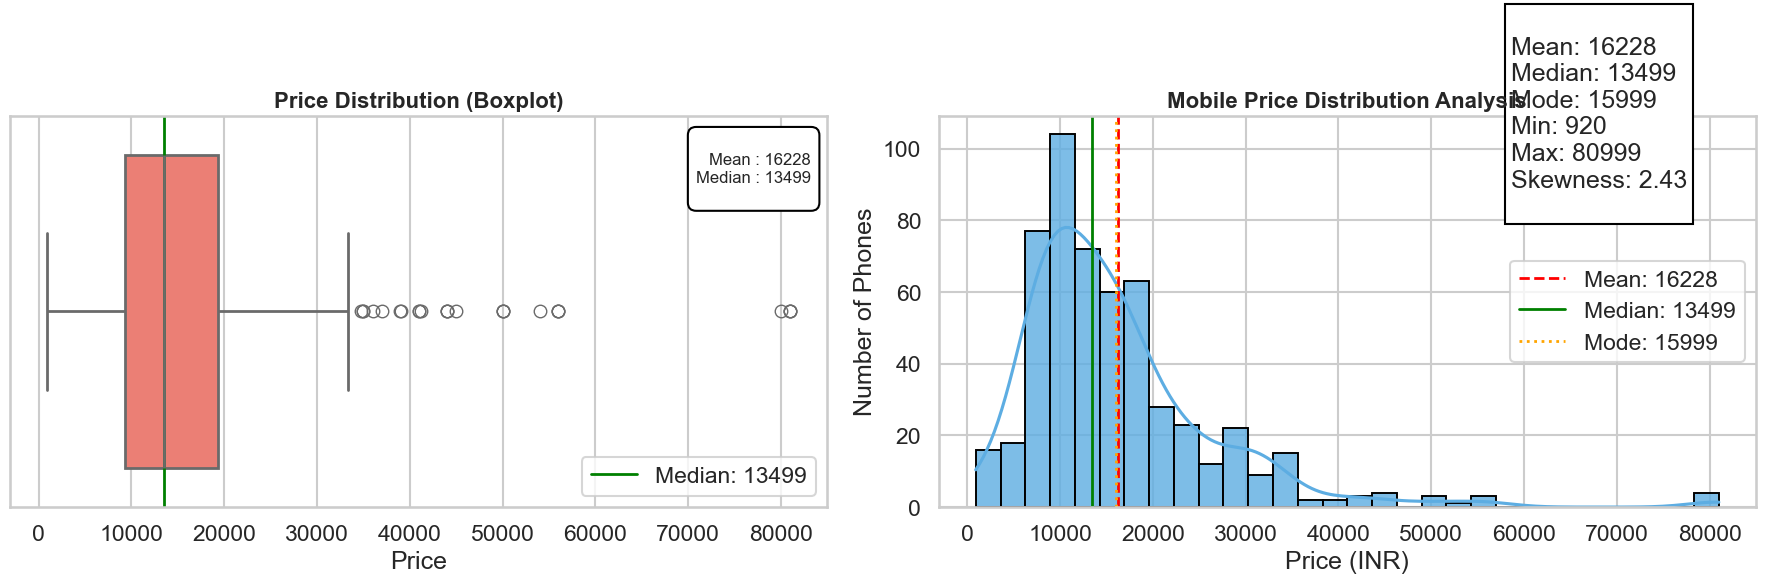

Skewness Value: 2.43
Distribution Type: Right Skewed


In [17]:
sns.set_style("whitegrid")
sns.set_palette("rocket")
sns.set_context("talk")

fig, axes = plt.subplots(1,2, figsize=(18,6))


# ===============================
# HISTOGRAM
# ===============================

ax = sns.histplot(
    df['Price'],
    bins=30,
    kde=True,
    ax=axes[1],
    color='#5DADE2',
    edgecolor='black',
    alpha=0.8
)
mean = df['Price'].mean()
median = df['Price'].median()
mode = df['Price'].mode()[0]
skewness_value = df['Price'].skew()

axes[1].axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean:.0f}')
axes[1].axvline(median, color='green', linestyle='-', linewidth=2, label=f'Median: {median:.0f}')
axes[1].axvline(mode, color='orange', linestyle=':', linewidth=2, label=f'Mode: {mode:.0f}')

if skewness_value > 0:
    skew_type = "Right Skewed"
elif skewness_value < 0:
    skew_type = "Left Skewed"
else:
    skew_type = "Symmetric"

stats = f"""
Mean: {mean:.0f}
Median: {median:.0f}
Mode: {mode:.0f}
Min: {df['Price'].min()}
Max: {df['Price'].max()}
Skewness: {skewness_value:.2f}
"""

axes[1].text(
    0.70, 0.75,
    stats,
    transform=axes[1].transAxes,
    bbox=dict(facecolor='white', edgecolor='black')
)

axes[1].set_title("Mobile Price Distribution Analysis", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Price (INR)")
axes[1].set_ylabel("Number of Phones")
axes[1].legend()

# ===============================
# BOX PLOT
# ===============================

sns.boxplot(
    x=df['Price'],
    ax=axes[0],
    color='#FF6F61',
    linewidth=2
)

mean = df['Price'].mean()
median = df['Price'].median()

# axes[0].axvline(mean, color='blue', linestyle='--', linewidth=2, label=f"Mean: {mean:.0f}")
axes[0].axvline(median, color='green', linestyle='-', linewidth=2, label=f"Median: {median:.0f}")

stats_text = f"""
Mean : {mean:.0f}
Median : {median:.0f}
"""

axes[0].text(
    0.98, 0.95,
    stats_text,
    transform=axes[0].transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5')
)

axes[0].set_title("Price Distribution (Boxplot)", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Price")
axes[0].legend()

plt.tight_layout()
plt.show()

print("Skewness Value:", round(skewness_value,2))
print("Distribution Type:", skew_type)

### Price Distribution Overview

The distribution of smartphone prices reveals important characteristics of the dataset. The **boxplot** highlights the spread of prices and helps identify potential outliers, while the **histogram with KDE** illustrates how prices are distributed across different ranges.

The comparison between the **mean, median, and mode** suggests that the price distribution is **right-skewed**, meaning a larger number of smartphones are concentrated in the lower to mid-price ranges, while a smaller set of premium devices extends the distribution toward higher prices.

This pattern is typical in consumer electronics markets, where **budget and mid-range devices dominate the market**, and a limited number of flagship models drive the higher price range.

Overall, the visualization indicates that most smartphones in the dataset fall within a moderate price band, with a few high-priced devices contributing to the skewness of the distribution.

In [18]:
# Calculate Quartiles
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

# IQR
IQR = Q3 - Q1

# Outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# # Identify outliers
outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Total Outliers:", len(outliers))


Q1: 9290.0
Q3: 19280.0
IQR: 9990.0
Lower Bound: -5695.0
Upper Bound: 34265.0
Total Outliers: 25


**Outlier Analysis**

Outliers in the Price feature were detected using the IQR method and visualized using boxplots.

Several devices such as Samsung Galaxy S23, Google Pixel 7, and Apple iPhone models were identified as statistical outliers.

However, further inspection revealed that these observations correspond to **premium flagship smartphones rather than data errors**.

Since these devices represent legitimate high-end market segments, removing them would distort the natural price distribution and negatively impact model learning.

Therefore, the outliers were **retained in the dataset** to ensure the model captures the full spectrum of smartphone pricing

---

**2. ECDF Analysis of Price**


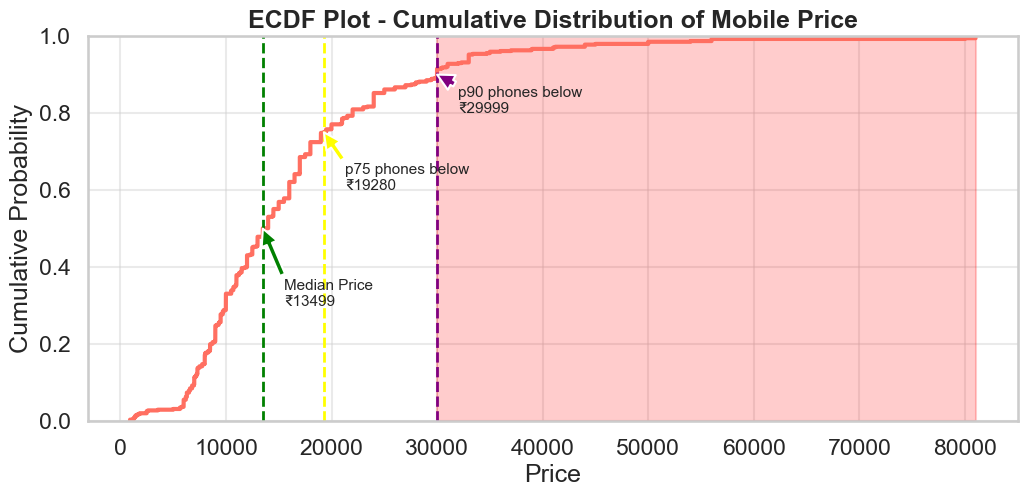

In [19]:
plt.figure(figsize=(12, 5))

sns.ecdfplot(
    df['Price'],
    linewidth= 3,
    color = '#FF6F61'
)

# Calculate Statistics

median = df['Price'].median()
p75 = df['Price'].quantile(0.75)
p90 = df['Price'].quantile(0.90)


# Vertical Lines

plt.axvline(median, linestyle= '--', color = 'green', linewidth=2)
plt.axvline(p75, linestyle= '--', color = 'yellow', linewidth=2)
plt.axvline(p90, linestyle= '--', color = 'purple', linewidth=2)

# Annotation

plt.annotate(
    f"Median Price\n₹{median:.0f}",
    xy= (median, 0.5),
    xytext= (median+2000, 0.3),
    arrowprops = dict(facecolor='green'),
    fontsize=11
)

plt.annotate(
    f"p75 phones below\n₹{p75:.0f}",
    xy= (p75, 0.75),
    xytext= (p75+2000, 0.6),
    arrowprops = dict(facecolor = 'yellow'),
    fontsize=11
)

plt.annotate(
    f"p90 phones below \n₹{p90:.0f}",
    xy= (p90, 0.90),
    xytext= (p90+2000, 0.8),
    arrowprops= dict(facecolor = 'purple'),
    fontsize=11
)

plt.title("ECDF Plot - Cumulative Distribution of Mobile Price", fontsize = 18, fontweight='bold')

plt.xlabel('Price')
plt.ylabel('Cumulative Probability')
plt.axvspan(p90, df['Price'].max(), alpha=0.2, color='red')
plt.grid(alpha = 0.4)

plt.show()

### ECDF Analysis — Understanding Price Concentration

The ECDF (Empirical Cumulative Distribution Function) plot provides a cumulative view of how smartphone prices are distributed across the dataset. Unlike a histogram, which shows frequency within price ranges, the ECDF directly indicates **what proportion of phones fall below a specific price point**.

From the plot, the **median price** marks the point where half of the smartphones are priced below this value, giving a clear reference for the typical market price. The **75th percentile (P75)** shows that about three-quarters of the devices fall below this threshold, representing the upper range of mainstream smartphones. The **90th percentile (P90)** further highlights that the vast majority of phones lie below this price, while only a small fraction belong to the premium segment.

The shaded region beyond the 90th percentile represents **high-end devices**, indicating that flagship smartphones make up only a small portion of the dataset. Overall, the ECDF plot reinforces that the market is largely dominated by **budget and mid-range smartphones**, with relatively few devices occupying the premium price tier.

-------

**B: RAM**

**1. Count Plot and Histogram(RAM Frequency)**

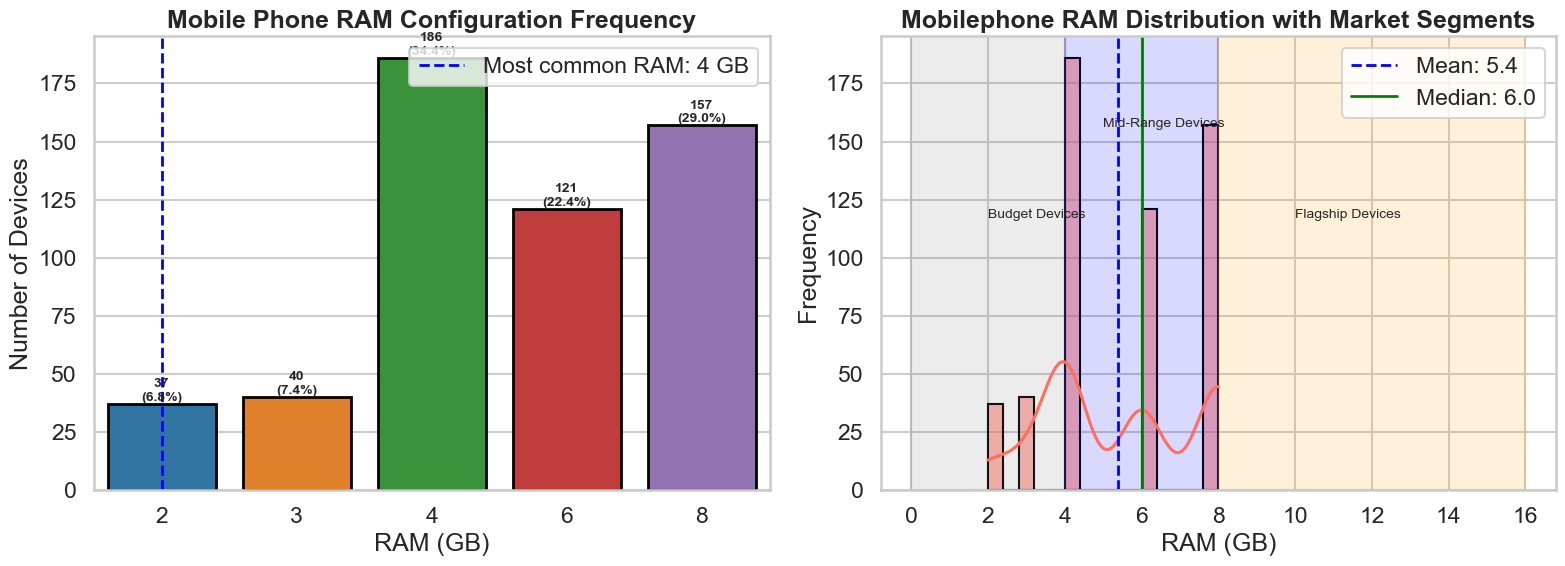

In [20]:
sns.set_style('whitegrid')
sns.set_context('talk')

fig, axes = plt.subplots(1,2, figsize=(16,6))

# ===============================
# RAM COUNT PLOT
# ===============================

ax = sns.countplot(
    x='RAM',
    data=df,
    palette='tab10',
    linewidth=2,
    edgecolor='black',
    ax=axes[0]
)

total = len(df)

# Add labels and percentages
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'

    ax.annotate(
        f'{count}\n({percentage})',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Most common RAM
most_common_ram = df['RAM'].mode()[0]

ax.axvline(
    x=df['RAM'].unique().tolist().index(most_common_ram),
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Most common RAM: {most_common_ram} GB'
)

axes[0].set_title('Mobile Phone RAM Configuration Frequency', fontweight='bold')
axes[0].set_xlabel('RAM (GB)')
axes[0].set_ylabel('Number of Devices')
axes[0].legend()

# ===============================
# RAM HISTOGRAM
# ===============================

sns.histplot(
    df['RAM'],
    bins=15,
    kde=True,
    color='#FF6F61',
    edgecolor='black',
    ax=axes[1]
)

mean = df['RAM'].mean()
median = df['RAM'].median()

axes[1].axvline(mean, linestyle='--', color='blue', linewidth=2, label=f"Mean: {mean:.1f}")
axes[1].axvline(median, linestyle='-', color='green', linewidth=2, label=f"Median: {median:.1f}")

# Market segments
axes[1].axvspan(0,4,alpha=0.15,color='gray')
axes[1].axvspan(4,8,alpha=0.15,color='blue')
axes[1].axvspan(8,16,alpha=0.15,color='orange')

axes[1].annotate("Budget Devices", xy=(2,axes[1].get_ylim()[1]*0.6), fontsize=10)
axes[1].annotate("Mid-Range Devices", xy=(5,axes[1].get_ylim()[1]*0.8), fontsize=10)
axes[1].annotate("Flagship Devices", xy=(10,axes[1].get_ylim()[1]*0.6), fontsize=10)

axes[1].set_title("Mobilephone RAM Distribution with Market Segments", fontweight='bold')
axes[1].set_xlabel("RAM (GB)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

### RAM Configuration Analysis

The RAM analysis highlights both the **frequency of different RAM configurations** and their **overall distribution across smartphones**. The count plot shows that a few RAM options dominate the dataset, with one configuration appearing most frequently, indicating the current market standard.

The histogram further reveals how RAM is distributed across device segments. Lower RAM capacities represent **budget devices**, mid-range RAM sizes correspond to **mainstream smartphones**, and higher RAM capacities characterize **flagship devices**.

Overall, the distribution suggests that most devices cluster around the **mid-range RAM segment**, reflecting the balance manufacturers aim for between performance and affordability in the smartphone market.

-------

## C. Memory

**1. Memory Distribution Analysis — Histogram with KDE**

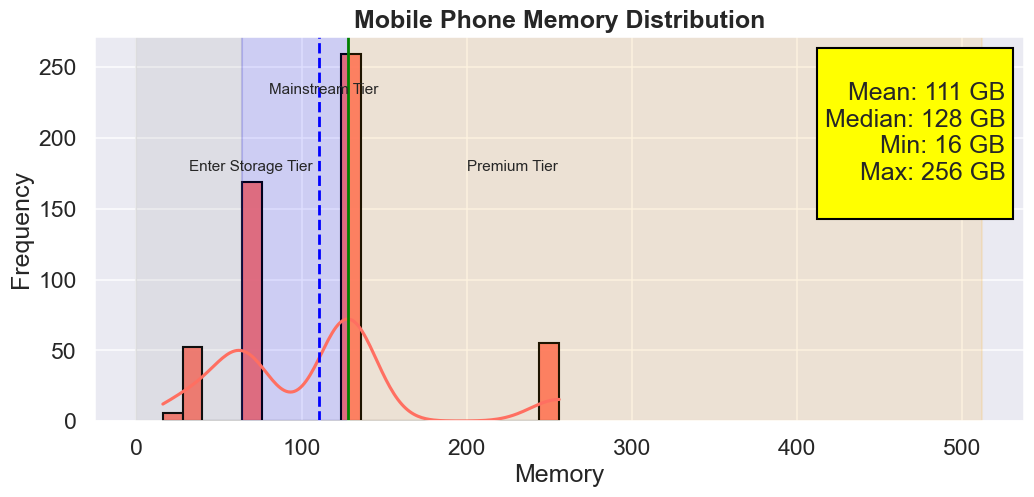

In [21]:
sns.set_style('dark')
sns.set_palette('rocket')
sns.set_context('talk')

# Plotting Histogram + KDE

plt.figure(figsize = (12, 5))

sns.histplot(
    df['Memory'],
    bins= 20,
    kde = True,
    color = '#FF6F61',
    edgecolor = 'black',
    alpha = 0.9
)

# Central Tendency

mean = df['Memory'].mean()
median = df['Memory'].median()

# Plotting Lines

plt.axvline(mean, color = 'blue', linestyle = '--', linewidth = 2, label = f"Mean: {mean:.0f} GB")
plt.axvline(median, color = 'green', linestyle = '-', linewidth = 2, label = f"Median: {median:.0f} GB")

# Typical Mobile Phone Features

plt.axvspan(0, 64, alpha = 0.12, color = 'gray')
plt.axvspan(64, 128, alpha = 0.12, color = 'blue')
plt.axvspan(128, 512, alpha = 0.12, color = 'orange')

# Annotation

plt.annotate('Enter Storage Tier',
             xy=(32, plt.ylim()[1]*0.65),
             fontsize=11)

plt.annotate('Mainstream Tier',
             xy= (80, plt.ylim()[1]*0.85),
             fontsize=11)

plt.annotate('Premium Tier',
             xy=(200, plt.ylim()[1]*0.65),
             fontsize=11)

# Stats Box

stats_text = f"""
Mean: {mean:.0f} GB
Median: {median:.0f} GB
Min: {df['Memory'].min()} GB
Max: {df['Memory'].max()} GB
"""

plt.text(
    0.98, 0.95,
    stats_text,
    transform = plt.gca().transAxes,
    verticalalignment = 'top',
    horizontalalignment = 'right',
    bbox = dict(facecolor = 'yellow', edgecolor = 'black', boxstyle='square')
)

plt.title('Mobile Phone Memory Distribution', fontsize=18, fontweight='bold')
plt.xlabel('Memory')
plt.ylabel('Frequency')

plt.grid(alpha=0.7)

plt.legend

plt.show()

### Mobile Memory Distribution

The distribution of smartphone storage highlights how devices are positioned across different market tiers. Most phones cluster within the **64–128 GB range**, indicating that this storage capacity has become the **mainstream standard** for modern smartphones.

Lower storage capacities represent **entry-level devices**, typically designed for basic usage and affordability. In contrast, higher capacities such as **128 GB and above** correspond to **premium devices**, catering to users who require more space for apps, media, and high-resolution content.

The close alignment between the **mean and median** suggests that storage distribution is relatively balanced, though the presence of higher-capacity devices extends the upper range. Overall, the pattern reflects how manufacturers increasingly prioritize **larger storage options** to meet growing consumer demands for multimedia, gaming, and app-heavy usage.

----

**D. Battery**

**1. Histogram + KDE and Box Plot**

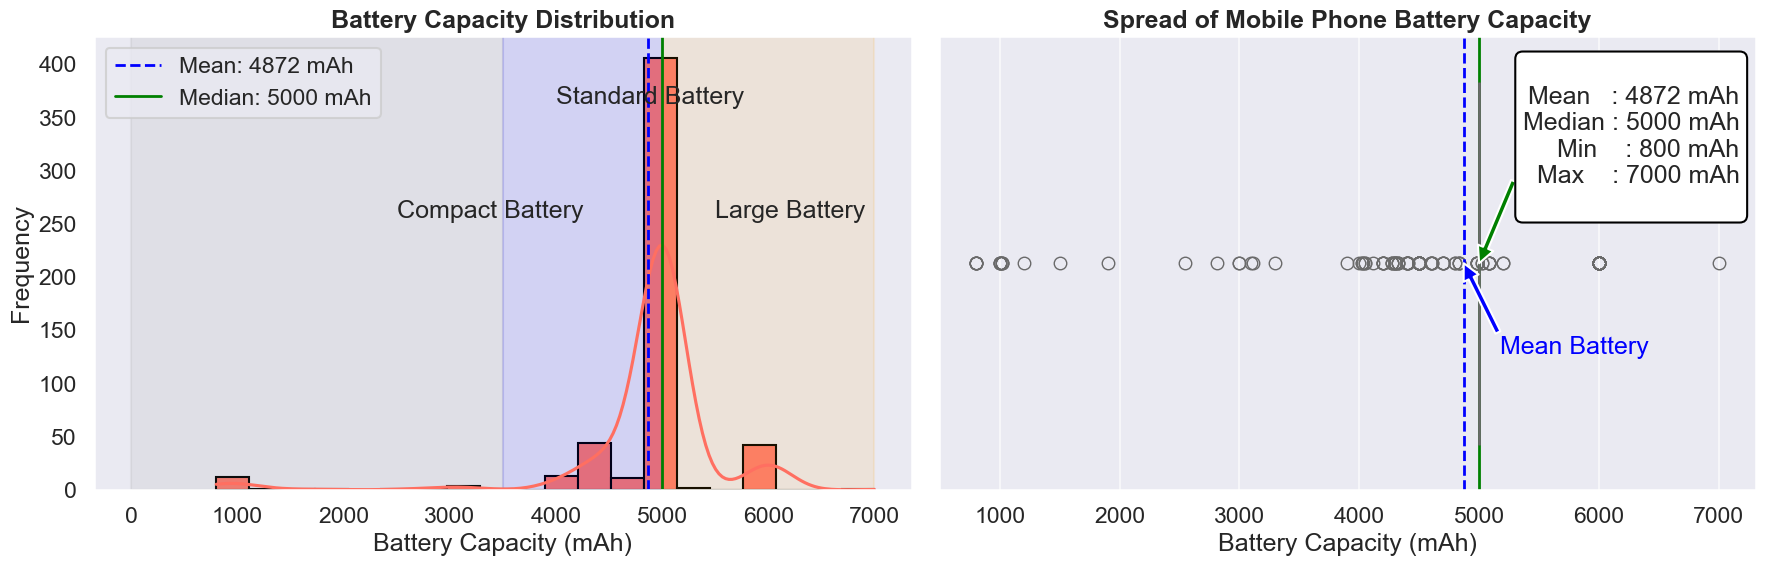

In [22]:
sns.set_style('dark')
sns.set_context('talk')

fig, axes = plt.subplots(1,2, figsize=(18,6))

# ==================================
# HISTOGRAM + KDE
# ==================================

sns.histplot(
    df['Battery'],
    bins=20,
    kde=True,
    color='#FF6F61',
    edgecolor='black',
    alpha=0.9,
    ax=axes[0]
)

mean = df['Battery'].mean()
median = df['Battery'].median()

axes[0].axvline(mean, color='blue', linestyle='--', linewidth=2, label=f"Mean: {mean:.0f} mAh")
axes[0].axvline(median, color='green', linestyle='-', linewidth=2, label=f"Median: {median:.0f} mAh")

# Battery tiers
axes[0].axvspan(0,3500,alpha=0.1,color='gray')
axes[0].axvspan(3500,5000,alpha=0.1,color='blue')
axes[0].axvspan(5000,7000,alpha=0.1,color='orange')

axes[0].annotate('Compact Battery', xy=(2500, axes[0].get_ylim()[1]*0.6))
axes[0].annotate('Standard Battery', xy=(4000, axes[0].get_ylim()[1]*0.85))
axes[0].annotate('Large Battery', xy=(5500, axes[0].get_ylim()[1]*0.6))

axes[0].set_title('Battery Capacity Distribution', fontweight='bold')
axes[0].set_xlabel('Battery Capacity (mAh)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# ==================================
# BOXPLOT
# ==================================

sns.boxplot(
    x=df['Battery'],
    color='#FF6F61',
    linewidth=2,
    ax=axes[1]
)

axes[1].axvline(mean, color='blue', linestyle='--', linewidth=2)
axes[1].axvline(median, color='green', linestyle='-', linewidth=2)

axes[1].annotate(
    'Mean Battery',
    xy=(mean,0),
    xytext=(mean+300,0.2),
    arrowprops=dict(facecolor='blue'),
    color='blue'
)

axes[1].annotate(
    'Median Battery',
    xy=(median,0),
    xytext=(median+300,-0.2),
    arrowprops=dict(facecolor='green'),
    color='green'
)

stats_text = f"""
Mean   : {mean:.0f} mAh
Median : {median:.0f} mAh
Min    : {df['Battery'].min()} mAh
Max    : {df['Battery'].max()} mAh
"""

axes[1].text(
    0.98,0.95,
    stats_text,
    transform=axes[1].transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white',edgecolor='black',boxstyle='round')
)

axes[1].set_title("Spread of Mobile Phone Battery Capacity", fontweight='bold')
axes[1].set_xlabel("Battery Capacity (mAh)")
axes[1].grid(axis='x', alpha=0.6)

plt.tight_layout()
plt.show()

### Battery Capacity Insights

The battery analysis combines a distribution view and a spread analysis to better understand how smartphone battery capacities vary across devices. The histogram shows that most phones cluster around the **standard battery range (3500–5000 mAh)**, which reflects the typical balance between device size and daily usage requirements.

Lower capacities correspond to **compact devices**, while batteries above 5000 mAh indicate **large-battery smartphones designed for extended usage** such as gaming or media consumption.

The boxplot complements this by highlighting the **overall spread and potential outliers**, while the proximity of the mean and median suggests that battery capacities are relatively concentrated around the standard range. Overall, the dataset indicates that manufacturers primarily target the **mid-capacity segment**, with fewer devices at the extreme ends.

------

In [23]:
# Calculate Quartiles
Q1 = df['Battery'].quantile(0.25)
Q3 = df['Battery'].quantile(0.75)

# IQR
IQR = Q3 - Q1

# Outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# # Identify outliers
outliers = df[(df['Battery'] < lower_bound) | (df['Battery'] > upper_bound)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Total Outliers:", len(outliers))


Q1: 5000.0
Q3: 5000.0
IQR: 0.0
Lower Bound: 5000.0
Upper Bound: 5000.0
Total Outliers: 152


**Outlier Analysis**

Outliers were detected using boxplots and the IQR method.

Upon inspection, most extreme values correspond to premium or flagship smartphones with higher RAM, storage, and camera specifications.

Since these values represent legitimate market segments rather than data entry errors, the outliers were retained to preserve the natural price distribution of the dataset.

**E: Colour**

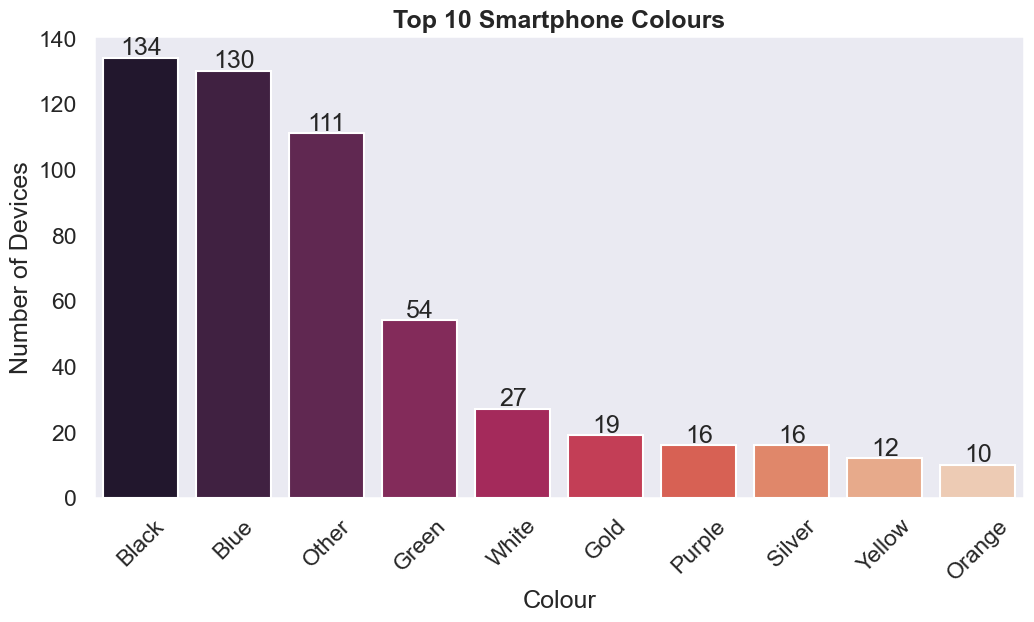

In [24]:
top_colors = df['Colour_Group'].value_counts().nlargest(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_colors.index,
    y=top_colors.values,
    palette="rocket"
)

for i, v in enumerate(top_colors.values):
    ax.text(i, v + 1, str(v), ha='center')

plt.title("Top 10 Smartphone Colours", fontsize=18, fontweight='bold')

plt.xlabel("Colour")
plt.ylabel("Number of Devices")

plt.xticks(rotation=45)

plt.show()

### Top Mobilephone Colour Preferences

The bar chart highlights the **most common smartphone colour options** available in the dataset. A few colours clearly dominate the market, indicating that manufacturers tend to prioritize **popular, widely accepted shades** rather than offering too many niche options.

These dominant colours likely reflect **consumer preferences for neutral and versatile designs**, which appeal to a broader audience. Meanwhile, the remaining colours appear less frequently, suggesting they are offered as **limited or stylistic variations** rather than mainstream choices.

Overall, the distribution shows that smartphone colour offerings are **concentrated around a small set of highly preferred options**, aligning with typical market demand and product design strategies.

------

**E. Processor_Brand — Market Share Visualization**

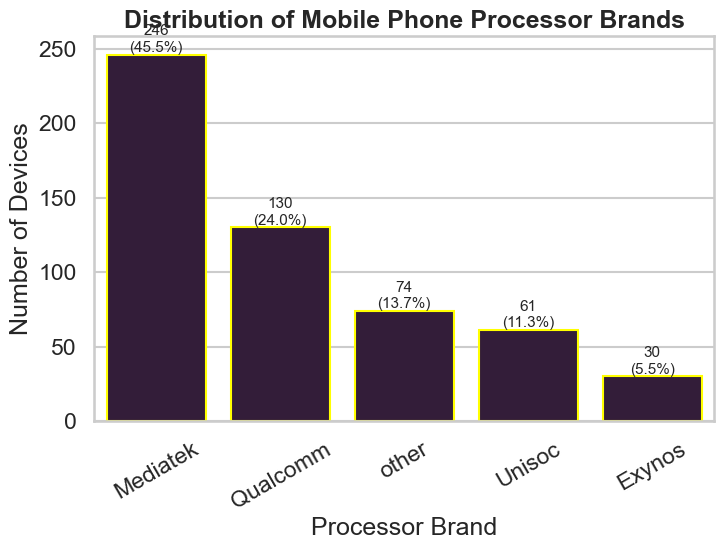

In [25]:
sns.set_style("whitegrid")
sns.set_palette("rocket")
sns.set_context("talk")

counts = df['Processor_Brand'].value_counts()

# Identify dominant processor
dominant = counts.idxmax()

# Assign colors
colors = ['#FF6F61' if brand == dominant else '#B0B0B0' 
          for brand in counts.index]

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    x='Processor_Brand',
    data=df,
    order=df['Processor_Brand'].value_counts().index,
    edgecolor='yellow'
)

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    
    ax.annotate(
        f'{count}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width()/2., count),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Distribution of Mobile Phone Processor Brands", fontsize=18, fontweight='bold')

plt.xlabel("Processor Brand")
plt.ylabel("Number of Devices")

plt.xticks(rotation=30)

plt.show()


### Processor Brand Distribution

The visualization highlights how different processor brands are represented across smartphones in the dataset. One processor brand clearly dominates the distribution, suggesting it is the **most widely adopted chipset among manufacturers**, while the remaining brands appear less frequently.

This pattern reflects how the smartphone industry often relies on a **small set of major chipset providers**, with certain brands powering a large portion of devices due to their performance, efficiency, and strong manufacturer partnerships.

Overall, the distribution indicates that smartphone hardware ecosystems are **concentrated around a few key processor brands**, which play a major role in shaping device performance and market competition.

-----

### Bivariate Analysis (Feature Interaction and Relationship Profiling)

Bivariate analysis explores the **relationship between two variables**, primarily focusing on how different smartphone features relate to the **target variable (Price)**. This helps identify whether changes in specifications such as RAM, memory, or battery capacity are associated with changes in device pricing.

By examining feature–price relationships, we can detect **patterns, trends, and potential correlations** that indicate which specifications are likely to influence smartphone prices.

From a business perspective, this analysis helps reveal **key drivers of pricing**, highlight **feature combinations common in premium devices**, and provide early signals about which variables may serve as **strong predictors in the machine learning model**.

-----

**1: RAM vs Price**

It analyzes how mobile price varies with different RAM capacities to determine whether higher RAM significantly contributes to increased pricing.


**1.1: Scatter Plot & Line Plot**

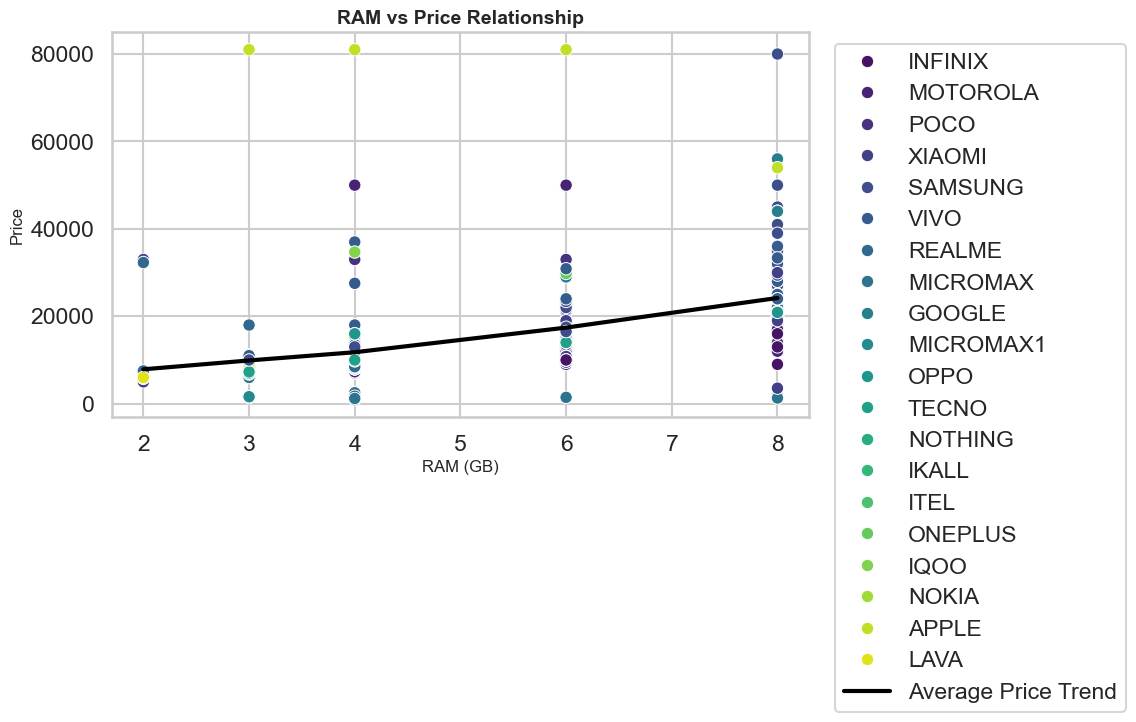

In [26]:
sns.set_style("whitegrid")
sns.set_context("talk")

plt.figure(figsize=(9,5))

# Scatterplot
sns.scatterplot(
    x='RAM',
    y='Price',
    hue='Brand',
    palette='viridis',
    s=80,
    data=df
)

# Trend line
sns.lineplot(
    x='RAM',
    y='Price',
    data=df,
    color='black',
    estimator='mean',
    ci=None,
    linewidth=3,
    label='Average Price Trend'
)

plt.title("RAM vs Price Relationship", fontsize=14, fontweight='bold')
plt.xlabel("RAM (GB)", fontsize=12)
plt.ylabel("Price", fontsize=12)

plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')

plt.show()

### RAM vs Price Relationship

The visualization highlights the relationship between smartphone RAM and price. Each point represents a device, showing how prices vary across different RAM configurations and brands. 

The trend line indicates that **higher RAM capacities are generally associated with higher prices**, suggesting that memory size is an important factor in smartphone pricing. This pattern reflects how manufacturers position higher-RAM devices as **performance-oriented or premium models**, making RAM a strong predictor for price in the dataset.

-----

**2: Memory vs Price**

**2.1: Scatter Plot & Bar Plot**

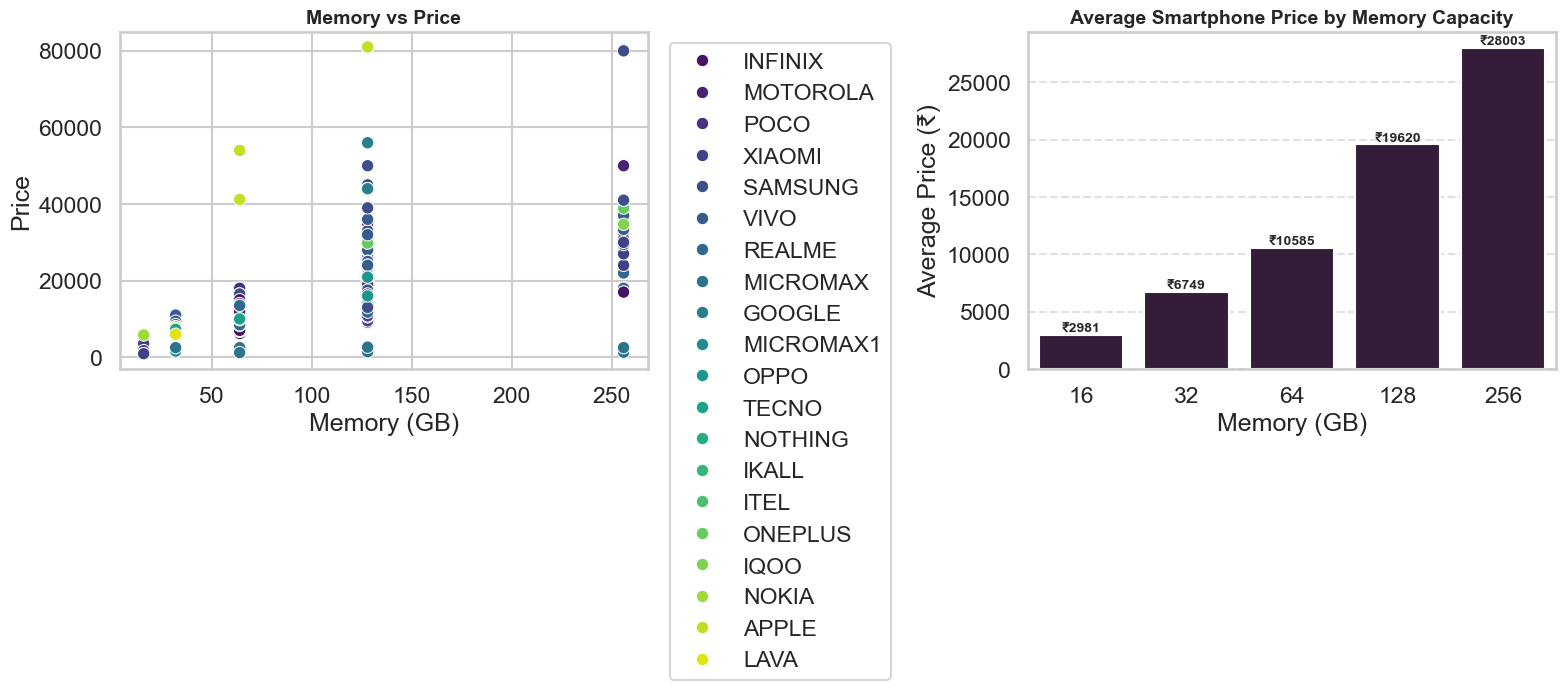

In [27]:
sns.set_style("whitegrid")
sns.set_context("talk")

fig, axes = plt.subplots(1,2, figsize=(16,6))

# ===============================
# Scatter Plot
# ===============================

sns.scatterplot(
    x='Memory',
    y='Price',
    hue='Brand',
    palette='viridis',
    s=80,
    data=df,
    ax=axes[0]
)

axes[0].set_title("Memory vs Price", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Memory (GB)")
axes[0].set_ylabel("Price")

axes[0].legend(bbox_to_anchor=(1.02,1), loc='upper left')


# ===============================
# Average Price Bar Plot
# ===============================

ax = sns.barplot(
    x='Memory',
    y='Price',
    data=df,
    estimator=np.mean,
    errorbar=None,
    ax=axes[1]
)

# Value labels
for p in ax.patches:
    ax.annotate(
        f"₹{p.get_height():.0f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

axes[1].set_title("Average Smartphone Price by Memory Capacity",
                  fontsize=14,
                  fontweight='bold')

axes[1].set_xlabel("Memory (GB)")
axes[1].set_ylabel("Average Price (₹)")

axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Memory vs Price Relationship

The visualization explores how smartphone storage capacity relates to device pricing. The scatter plot shows individual devices, highlighting how prices vary across different memory configurations and brands.

The bar chart complements this by showing the **average price for each memory tier**, making the overall pricing trend easier to interpret.

Together, the plots indicate that **higher storage capacities are generally associated with higher smartphone prices**, suggesting that memory size is an important factor influencing device positioning and pricing in the market.

-----

**3: Battery vs Price**

**3.1: Scatter Plot: Battery vs Price**

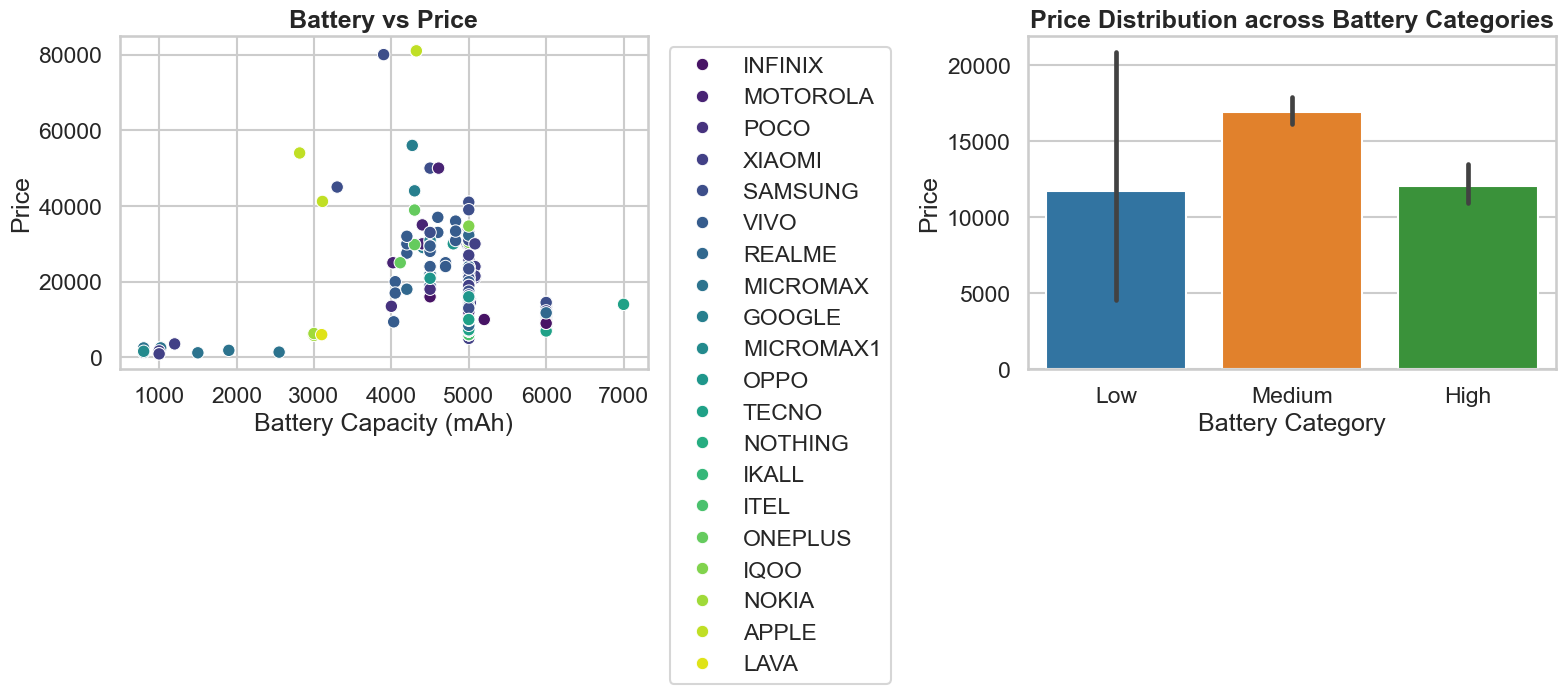

In [28]:
sns.set_style("whitegrid")
sns.set_context("talk")

fig, axes = plt.subplots(1,2, figsize=(16,6))

# =================================
# Scatter Plot: Battery vs Price
# =================================

sns.scatterplot(
    x='Battery',
    y='Price',
    hue='Brand',
    palette='viridis',
    s=80,
    data=df,
    ax=axes[0]
)

axes[0].set_title("Battery vs Price", fontweight='bold')
axes[0].set_xlabel("Battery Capacity (mAh)")
axes[0].set_ylabel("Price")

axes[0].legend(bbox_to_anchor=(1.02,1), loc='upper left')


# =================================
# Bar Plot: Battery Category vs Price
# =================================

sns.barplot(
    x='Battery Category',
    y='Price',
    data=df,
    palette='tab10',
    ax=axes[1]
)

axes[1].set_title("Price Distribution across Battery Categories",
                  fontweight='bold')
axes[1].set_xlabel("Battery Category")
axes[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

### Battery Capacity vs Price

The visualization examines how smartphone battery capacity relates to device pricing. The scatter plot shows individual devices, revealing how prices vary across different battery sizes and brands.

The bar chart groups devices into battery categories, making it easier to observe how pricing changes across battery tiers. Overall, while larger batteries may appear in higher-priced devices, the relationship is **less direct compared to features like RAM or memory**, suggesting battery capacity alone is not a primary driver of smartphone pricing.

---

**4: Colour vs Price**

**4.1: Count Plot & Bar Plot**

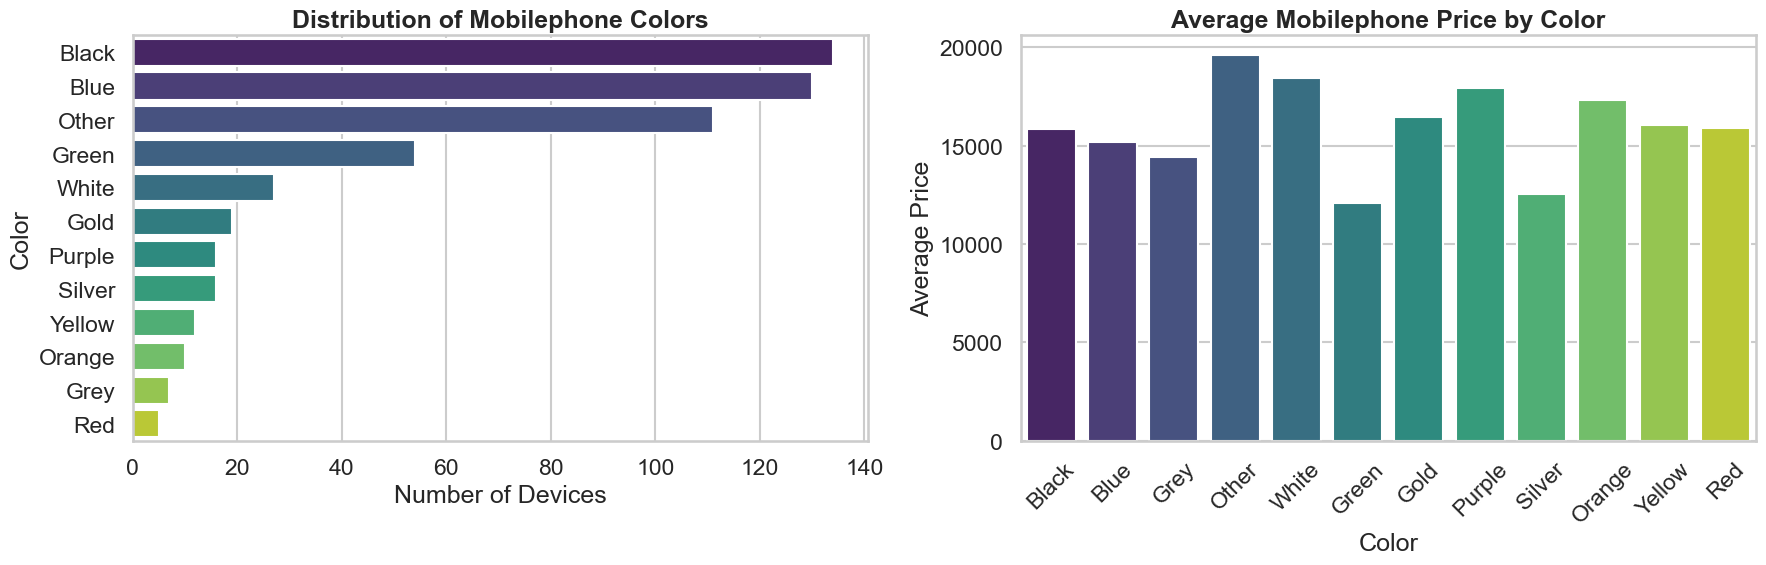

In [29]:
sns.set_style("whitegrid")
sns.set_context("talk")

fig, axes = plt.subplots(1,2, figsize=(18,6))

# =================================
# Color Distribution (Countplot)
# =================================

sns.countplot(
    y='Colour_Group',
    data=df,
    order=df['Colour_Group'].value_counts().index,
    palette='viridis',
    ax=axes[0]
)

axes[0].set_title('Distribution of Mobilephone Colors', fontweight='bold')
axes[0].set_xlabel('Number of Devices')
axes[0].set_ylabel('Color')


# =================================
# Average Price by Color (Barplot)
# =================================

sns.barplot(
    x='Colour_Group',
    y='Price',
    data=df,
    estimator=np.mean,
    errorbar=None,
    palette='viridis',
    ax=axes[1]
)

axes[1].set_title('Average Mobilephone Price by Color', fontweight='bold')
axes[1].set_xlabel('Color')
axes[1].set_ylabel('Average Price')

axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Smartphone Color Distribution and Pricing

The visualization compares the **frequency of mobilephone color options** with their **average pricing levels**. The count plot shows which colors are most commonly offered by manufacturers, reflecting general design preferences in the market.

The bar chart examines whether certain colors are associated with higher-priced devices. Overall, while some colors appear more frequently, pricing differences across colors are relatively limited, suggesting that **device color is primarily a design choice rather than a major factor influencing mobilephone price**.

----

## 8.3: Multivariate Analysis

**Multivariate Analysis**

Multivariate analysis examines the relationships between multiple variables simultaneously. Unlike univariate and bivariate analysis, which focus on individual variables or pairs of variables, multivariate analysis helps identify patterns and interactions among several features at the same time.

In this project, multivariate analysis is performed to understand how different mobilephone specifications interact with each other and how these combined effects influence mobile phone prices.

The following visualizations are used to explore these relationships:

* Correlation Heatmap to examine relationships among numerical variables
* Pairplot to visualize pairwise relationships between key features
* Interaction plots to analyze how multiple features jointly influence price

We should get answers to below questions:

1️⃣ Which features jointly influence price?

2️⃣ Which features are redundant or highly correlated?

3️⃣ Which features will help the model and which will hurt it?


These insights help identify the most influential predictors for building an effective price prediction model.

-----


**A. Correlation Matrix**

Goal: detect relationships between numerical variables.


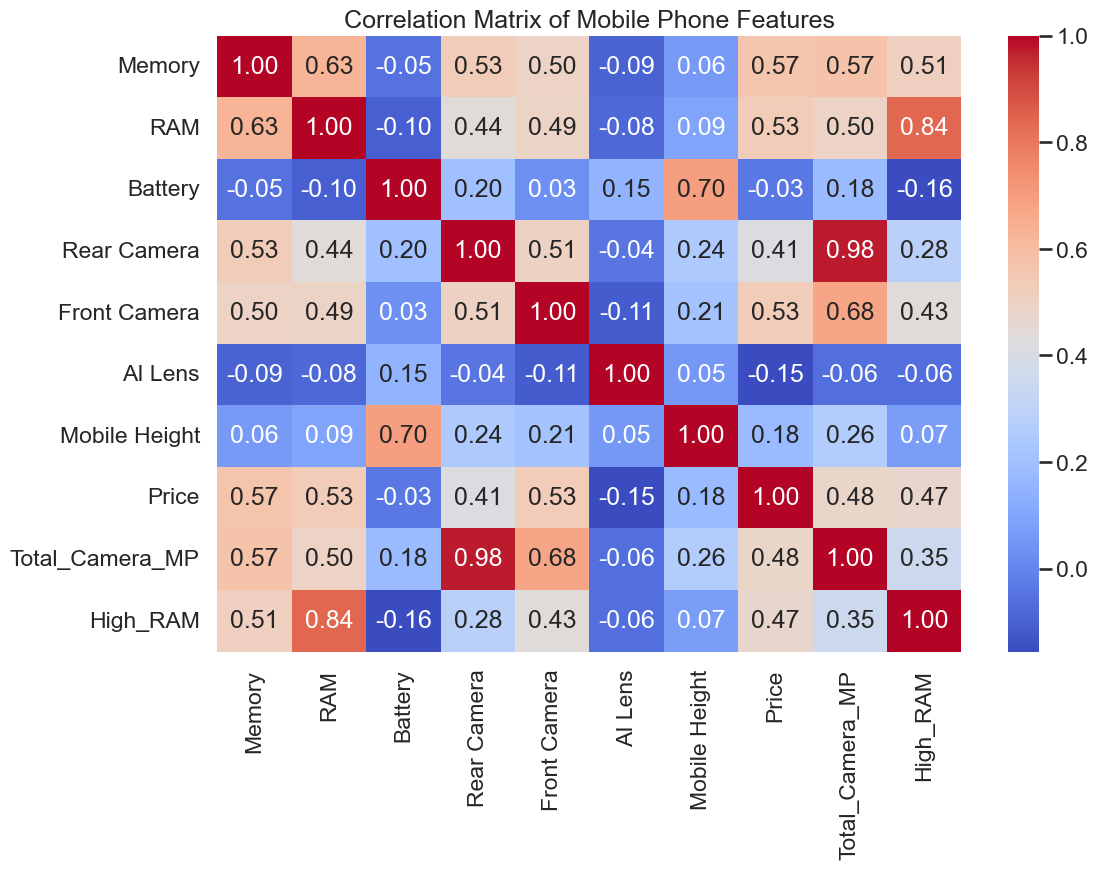

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Mobile Phone Features")

plt.show()

**Correlation Analysis**

The correlation heatmap provides insights into the relationships between numerical features.

RAM and Memory show a strong positive correlation with Price, indicating that devices with higher specifications tend to command higher prices.

Battery Capacity and Mobile Height exhibit weaker correlations with Price, suggesting they may have a smaller influence on pricing.

The correlation matrix also helps identify potential multicollinearity among predictors, which is important when building regression models.

__

**B. Multicollinearity Analysis**

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.select_dtypes(include=['int64','float64']).drop(columns=['Price'])

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data

,Feature,VIF
0,Memory,8.452170
1,RAM,29.268067
2,Battery,78.840752
3,Rear Camera,inf
4,Front Camera,inf
5,AI Lens,1.110498
6,Mobile Height,83.156480
7,Total_Camera_MP,inf
8,High_RAM,4.514397


**Multicollinearity Analysis**

Variance Inflation Factor (VIF) was calculated to detect multicollinearity among predictors.

High VIF values indicate that certain variables are highly correlated with other predictors and may introduce instability in regression models.

Features with very high VIF values should be carefully evaluated and potentially removed to improve model robustness.

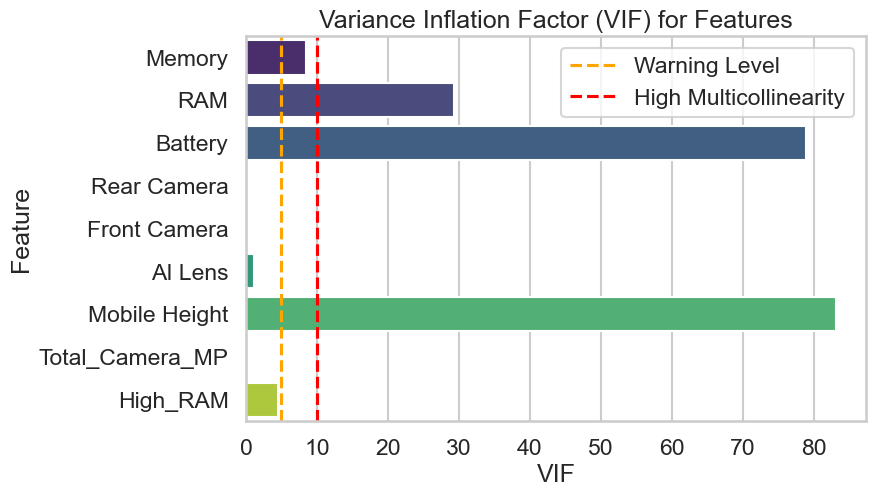

In [32]:
# BarPlot showcasing VIF - Multicollinearity Analysis
    
plt.figure(figsize=(8,5))

sns.barplot(
    x="VIF",
    y="Feature",
    data=vif_data,
    palette="viridis"
)

plt.axvline(5, color='orange', linestyle='--', label='Warning Level')
plt.axvline(10, color='red', linestyle='--', label='High Multicollinearity')

plt.title("Variance Inflation Factor (VIF) for Features")

plt.legend()

plt.show()

**Multicollinearity Analysis using Variance Inflation Factor (VIF)**

This bar chart visualizes the **Variance Inflation Factor (VIF) for each predictor feature** to detect potential multicollinearity within the dataset. VIF measures how strongly a feature is correlated with the other predictor variables.

The horizontal bars represent the **VIF score for each feature**, while the vertical reference lines indicate commonly used thresholds. The **orange dashed line (VIF = 5)** marks a warning level where moderate multicollinearity may begin to appear, and the **red dashed line (VIF = 10)** indicates a high level of multicollinearity that can negatively affect certain models.

Features with VIF values close to **1 suggest low correlation with other predictors**, meaning they contribute independent information to the model. Features with higher VIF values indicate that they share strong relationships with other variables, which may lead to unstable model coefficients and reduced interpretability. This visualization helps quickly identify whether any predictors require further investigation or removal due to multicollinearity.

------

**C: Pairplot (Pattern Discovery)**

Goal - See relationships across multiple features simultaneously.

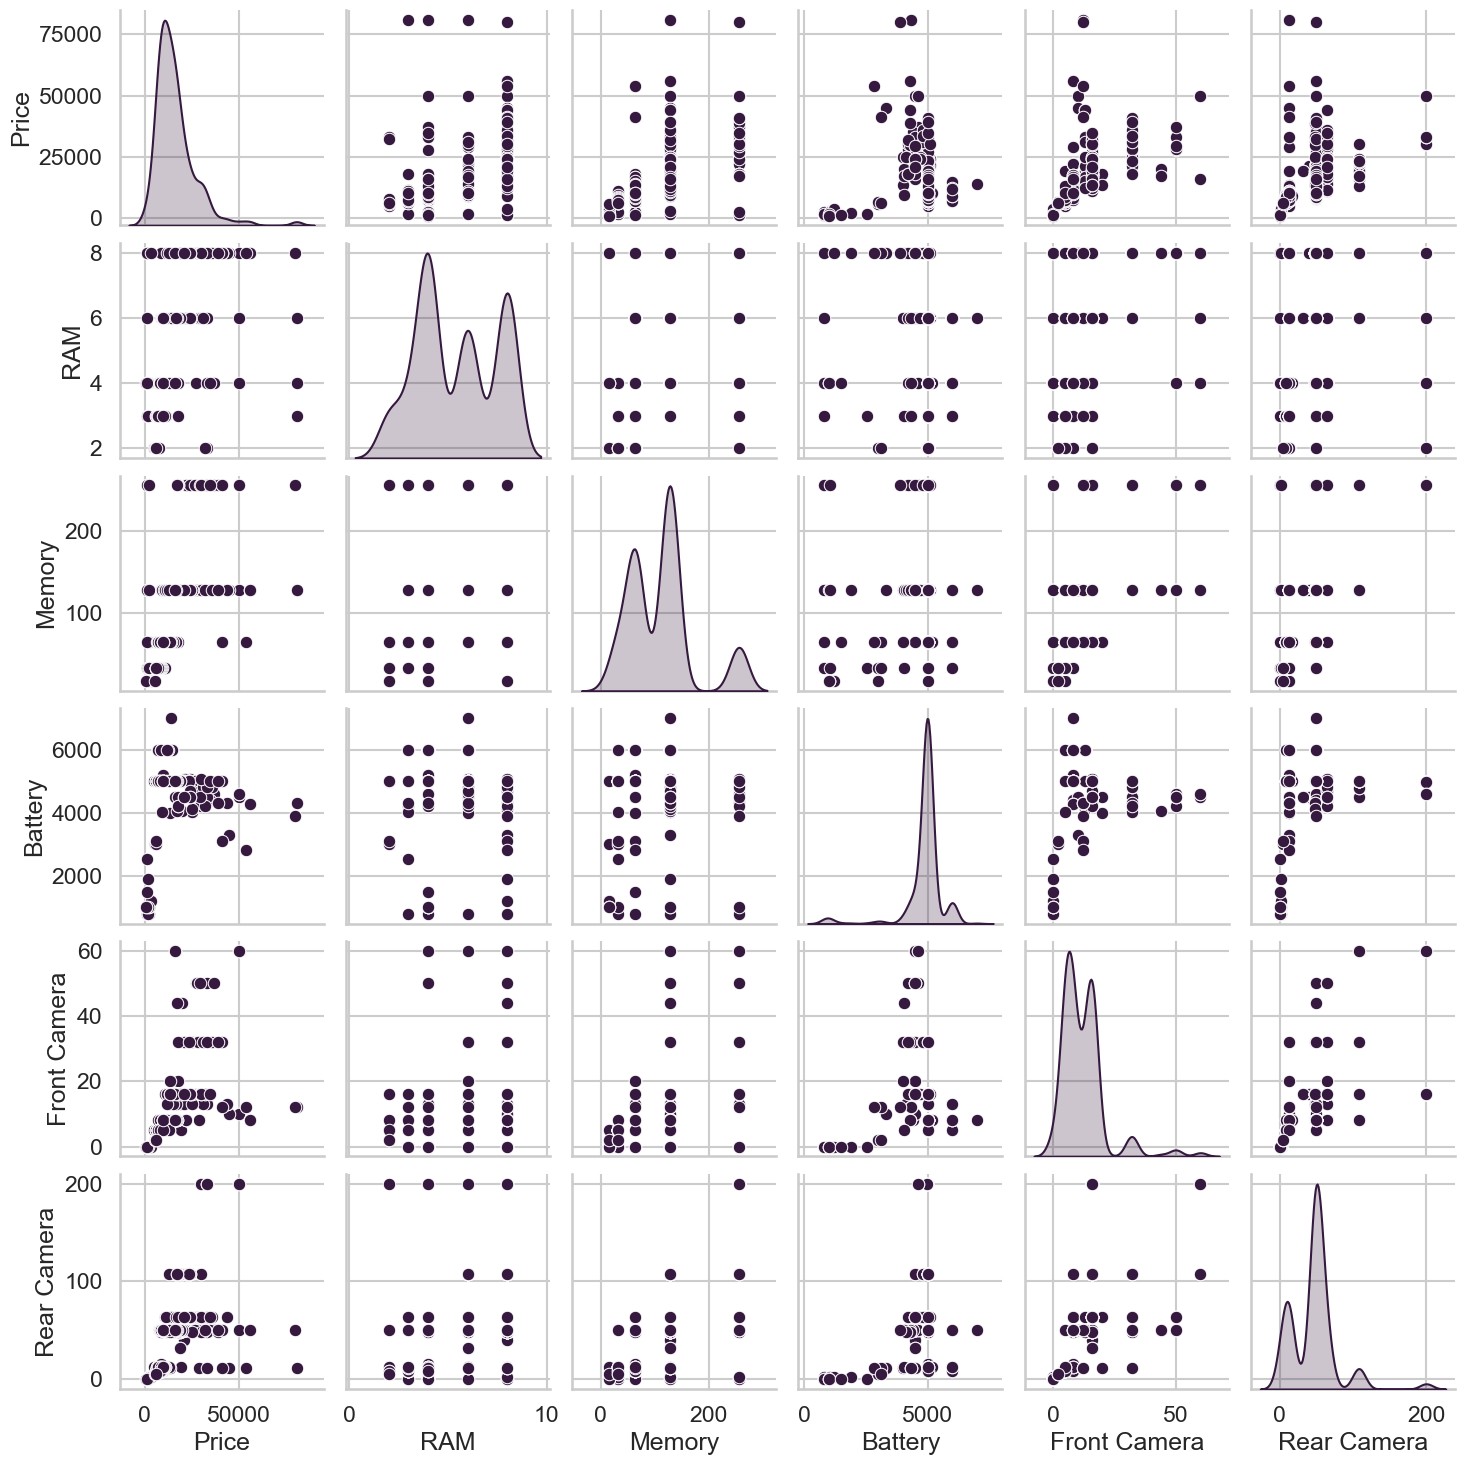

In [33]:
sns.pairplot(
    df[['Price','RAM','Memory','Battery','Front Camera', 'Rear Camera']],
    diag_kind='kde'
)

**Pairwise Feature Relationships**

A pairplot was used to visualize pairwise relationships between key numerical variables.

Clear upward trends are observed between RAM and Price as well as Memory and Price, reinforcing their importance as predictors.

This visualization also helps identify potential nonlinear relationships and clusters within the data.

-------

# STEP 9: Final Dataset Preparation

1️⃣ Define Target and Features

In [34]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Encoding**

In [36]:
X_train.select_dtypes(include='object').columns

Index(['Model', 'Colour', 'Processor', 'Processor_Brand', 'Brand',
       'Colour_Group', 'Processor_Class'],
      dtype='object')

In [37]:
# Separate features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
X.head()

,Memory,RAM,Battery,Rear Camera,Front Camera,AI Lens,Mobile Height,Total_Camera_MP,High_RAM,Model_APPLE iPhone 12,...,Colour_Group_Red,Colour_Group_Silver,Colour_Group_White,Colour_Group_Yellow,Battery Category_Medium,Battery Category_High,Storage_Tier_Mid,Storage_Tier_High,Storage_Tier_Ultra,Processor_Class_Mid
0,64,4,6000,13,5,1,16.76,18,0,False,...,False,False,False,False,False,True,False,False,False,False
1,64,4,6000,13,5,1,16.76,18,0,False,...,False,False,False,False,False,True,False,False,False,False
2,128,8,5000,50,16,0,16.64,66,1,False,...,False,False,False,False,True,False,True,False,False,False
3,32,2,5000,8,5,0,16.56,13,0,False,...,False,False,False,False,True,False,False,False,False,True
4,128,8,5000,50,5,1,16.76,55,1,False,...,False,False,False,False,True,False,True,False,False,True


In [39]:
X = pd.get_dummies(X, drop_first=True)

In [40]:
print(X_train.dtypes)

Memory                   int64
RAM                      int64
Battery                  int64
Rear Camera              int64
Front Camera             int64
                         ...  
Battery Category_High     bool
Storage_Tier_Mid          bool
Storage_Tier_High         bool
Storage_Tier_Ultra        bool
Processor_Class_Mid       bool
Length: 631, dtype: object


**Training Model**

1- Gradient Boosting

2- Random Forest

3 - XGBoost

In [41]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

In [42]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [43]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

**Evaluate Model**

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_test, pred):

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return mae, rmse, r2

gbr_results = evaluate_model(y_test, gbr_pred)
rf_results = evaluate_model(y_test, rf_pred)
xgb_results = evaluate_model(y_test, xgb_pred)

In [45]:
results = pd.DataFrame({
    "Model": ["Gradient Boosting", "Random Forest", "XGBoost"],
    "MAE": [gbr_results[0], rf_results[0], xgb_results[0]],
    "RMSE": [gbr_results[1], rf_results[1], xgb_results[1]],
    "R2 Score": [gbr_results[2], rf_results[2], xgb_results[2]]
})

results

,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,1598.018107,4404.791607,0.859229
1,Random Forest,1820.507972,4781.369723,0.834130
2,XGBoost,1446.110229,4067.083968,0.879987


### Model Performance Comparison

To evaluate the predictive performance of each model, three regression metrics were calculated: **MAE, RMSE, and R² Score**.

A custom evaluation function was used to compute these metrics for **Gradient Boosting, Random Forest, and XGBoost**. The results were then summarized in a comparison table to identify which model provides the most accurate price predictions.

This approach allows for a clear and consistent comparison of model performance before selecting the best model for further analysis.### Best Performing Model

Among the evaluated models, **XGBoost achieved the best performance** with the lowest MAE and RMSE, along with the highest R² score. This indicates that XGBoost provides the most accurate price predictions and captures the relationship between smartphone features and price more effectively than Gradient Boosting and Random Forest. Therefore, XGBoost was selected as the final model for further analysis and validation.

**Hyperparameter Tuning**

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Define parameter search space
param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

# Initialize model
xgb = XGBRegressor(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

# Train tuned model
random_search.fit(X_train, y_train)

# Best model
best_xgb = random_search.best_estimator_

# Predictions
xgb_pred = best_xgb.predict(X_test)

# Show best parameters
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_pred = best_xgb.predict(X_test)

mae = mean_absolute_error(y_test, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2 = r2_score(y_test, xgb_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 1407.3175048828125
RMSE: 3972.5887025968345
R2 Score: 0.8854987025260925


### Impact of Hyperparameter Tuning on XGBoost

After applying hyperparameter tuning, the XGBoost model showed a **slight improvement in predictive performance**. The original baseline model achieved an **R² score of 0.8799**, while the tuned model improved this to **0.8855**.

Although the increase is modest, it indicates that the optimized combination of parameters—such as the number of trees, learning rate, and tree depth—helped the model capture the relationship between smartphone features and price more effectively.

This improvement demonstrates that hyperparameter tuning can enhance model performance by refining how the algorithm learns patterns from the data. The **tuned XGBoost model was therefore selected as the final model** for subsequent validation and analysis.

----

## Cross Validation

In [50]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    X,
    y,
    cv=10,
    scoring="r2"
)

print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.68500924 0.73079991 0.83277428 0.89966232 0.92751652 0.72979569
 0.9012745  0.70043921 0.84617412 0.56035012]
Average CV Score: 0.7813795924186706


### Cross-Validation Results

To evaluate the stability and generalization capability of the tuned XGBoost model, **10-fold cross-validation** was performed using the **R² metric**. This technique splits the dataset into multiple folds and trains the model on different subsets of data, ensuring that the performance is not dependent on a single train–test split.

The cross-validation scores range from **0.56 to 0.93**, with an **average R² score of approximately 0.78**. This indicates that the model is able to explain about **78% of the variance in smartphone prices across different data splits**.

Although there is some variability between folds, several folds achieve **R² scores above 0.85**, suggesting that the model performs strongly on many subsets of the data. The lower scores in a few folds indicate that performance may vary depending on the specific distribution of devices within each split.

Overall, the cross-validation results confirm that the **tuned XGBoost model demonstrates strong predictive capability and reasonable stability**, making it suitable for predicting smartphone prices based on the available features.

---

## Feature Importance

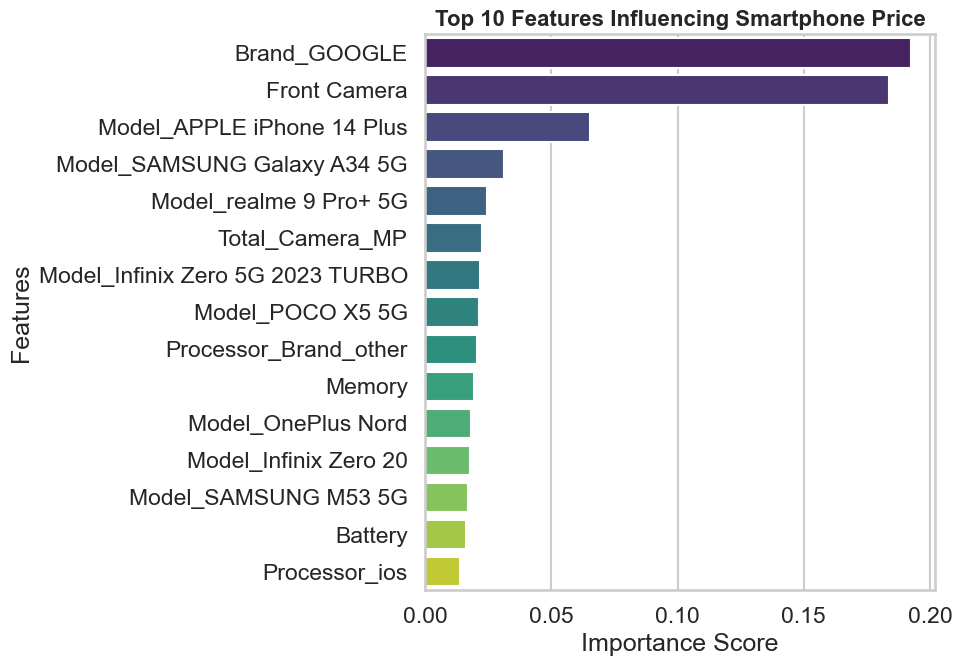

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create importance series
importance = pd.Series(
    best_xgb.feature_importances_,
    index=X.columns
)

# Sort and select top features
importance = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    x=importance.values,
    y=importance.index,
    palette="viridis"
)

plt.title("Top 10 Features Influencing Smartphone Price", fontsize=16, fontweight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.show()

### Feature Importance Analysis

Feature importance was analyzed using the tuned XGBoost model to identify which smartphone characteristics have the greatest influence on price prediction. 

The visualization highlights the top contributing features based on their importance scores. These scores represent how frequently and effectively each feature is used by the model to split the data during tree construction.

The results indicate that certain specifications—such as RAM, storage capacity, processor characteristics, and battery capacity—play a significant role in determining smartphone price. Understanding these influential features provides valuable insight into the factors that drive pricing in the smartphone market and supports the interpretability of the predictive model.

---

## SHAP EXplainability

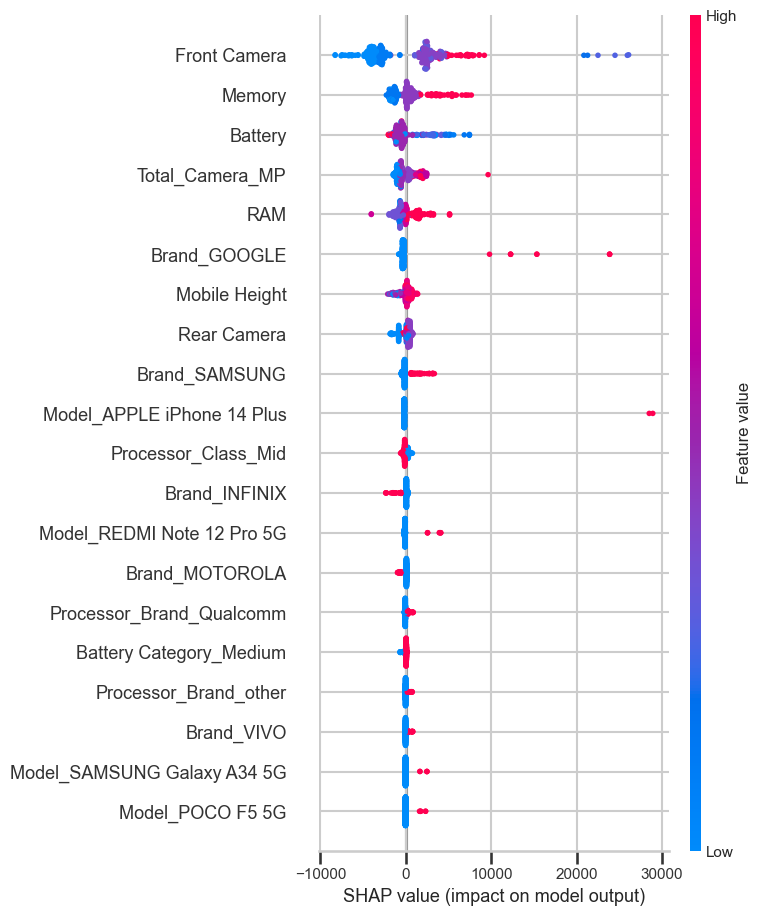

In [55]:
import shap

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

### SHAP Feature Importance Analysis

To gain deeper insight into how the model makes predictions, SHAP (SHapley Additive exPlanations) was used to interpret the XGBoost model. SHAP values quantify the contribution of each feature to the model's prediction, helping explain how different smartphone characteristics influence the predicted price.

The SHAP summary plot ranks features based on their overall impact on the model. Each point represents a single observation in the dataset, and the horizontal position indicates how strongly that feature pushes the prediction higher or lower. 

Features appearing at the top of the plot have the greatest influence on price predictions. Typically, variables such as **RAM, memory capacity, processor class, and battery capacity** tend to show higher importance, indicating that these specifications significantly affect smartphone pricing.

Overall, SHAP analysis provides a more detailed and interpretable view of model behavior, allowing us to understand **not only which features matter most but also how they influence the prediction direction**.

----

## Residual Analysis

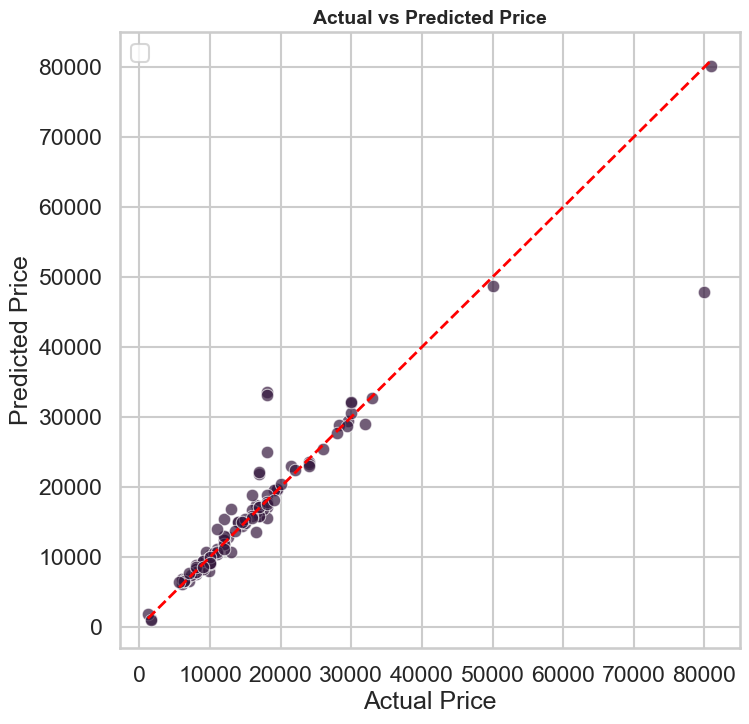

In [56]:
plt.figure(figsize=(8,8))

sns.scatterplot(
    x=y_test,
    y=xgb_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2,
    linestyle="--"
)

plt.title("Actual vs Predicted Price", fontsize = 14, fontweight='bold')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.legend()

plt.show()


### Actual vs Predicted Price (Model Performance Visualization)

This scatter plot compares the **actual smartphone prices** from the test dataset with the **prices predicted by the XGBoost model**. Each point in the plot represents a single smartphone observation, where the horizontal axis shows the **true price** and the vertical axis shows the **predicted price** generated by the model.

The dashed red diagonal line represents the **ideal prediction scenario**, where the predicted value is exactly equal to the actual value. Points that lie close to this line indicate **accurate predictions**, while points farther from the line represent larger prediction errors.

If most points cluster around the diagonal line, it suggests that the model is able to **capture the underlying relationship between smartphone features and price effectively**. Any noticeable deviations from the line highlight cases where the model **overestimates or underestimates the price**.

Overall, this visualization provides an intuitive way to assess how well the model’s predictions align with the actual smartphone prices.

----

## Error Distribion

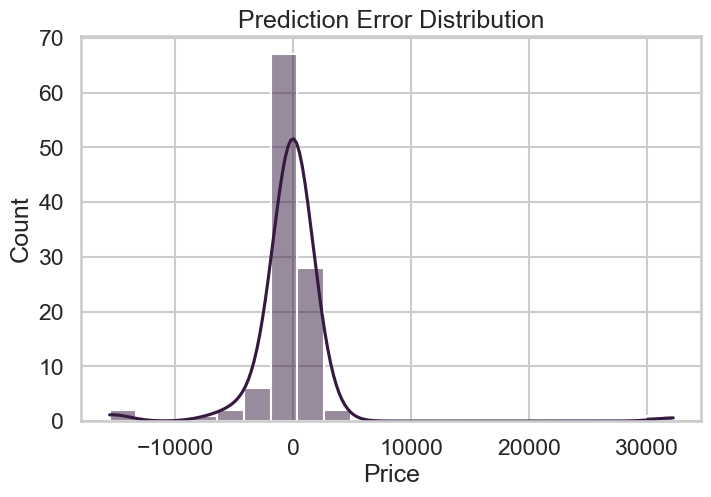

In [57]:
errors = y_test - xgb_pred

plt.figure(figsize=(8,5))

sns.histplot(errors, kde=True)

plt.title("Prediction Error Distribution")

plt.show()

### Prediction Error Distribution (Residual Analysis)

This visualization shows the **distribution of prediction errors (residuals)** from the XGBoost model. The error is calculated as the difference between the **actual smartphone price** and the **predicted price**.

A histogram is used to display how frequently different error values occur, while the KDE curve provides a smooth estimate of the error distribution.

Ideally, a well-performing regression model should produce errors that are **centered around zero**, indicating that the model does not consistently overpredict or underpredict prices. A symmetric and narrow distribution suggests that most predictions are close to the actual values.

Large deviations from zero represent cases where the model makes **larger prediction errors**, which may occur due to unusual feature combinations or limited representation of certain smartphone types in the dataset.

Overall, this plot helps evaluate the **accuracy and bias of the model**, ensuring that prediction errors are reasonably distributed rather than systematically skewed.

----

## Final Conclusion

The objective of this project was to develop a machine learning model capable of predicting smartphone prices based on key device specifications such as RAM, storage capacity, battery size, processor characteristics, and other hardware attributes. The project followed a structured data science workflow including exploratory data analysis, feature engineering, model development, evaluation, and interpretation.

### Key Insights from Exploratory Data Analysis

The exploratory analysis revealed several important patterns within the dataset. The price distribution showed that most smartphones fall within the **budget and mid-range segments**, while only a small portion of devices belong to the premium category. Features such as **RAM, memory capacity, and processor class** exhibited noticeable variation across devices, suggesting their potential influence on pricing.

Bivariate analysis further confirmed that **RAM and memory have strong positive relationships with smartphone prices**, indicating that devices with higher specifications tend to be priced higher. Battery capacity showed a weaker but still noticeable relationship with price, while color variations appeared to have minimal impact on pricing decisions.

### Feature Engineering

Several engineered features were introduced to improve the predictive capability of the models. These included categorical groupings such as **processor class, color groups, battery categories, and storage tiers**, which helped capture broader market segments rather than relying solely on raw values. This step helped reduce noise and improve model interpretability.

### Model Development and Comparison

Multiple machine learning models were trained and evaluated, including:

- Gradient Boosting Regressor  
- Random Forest Regressor  
- XGBoost Regressor  

Each model was evaluated using **Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R² score**. Among the tested algorithms, **XGBoost demonstrated the best overall performance**, achieving the highest R² score and lowest prediction errors compared to the other models.

### Hyperparameter Optimization

To further improve performance, hyperparameter tuning was conducted using RandomizedSearchCV. This process identified a more optimal set of parameters for the XGBoost model, resulting in a slight performance improvement, with the R² score increasing from approximately **0.88 to 0.885**. Although the improvement was modest, it indicates that the tuned model captures the relationships between smartphone specifications and pricing slightly more effectively.

### Model Validation

Cross-validation was performed to assess the model’s generalization ability across multiple subsets of the dataset. The average cross-validation R² score was approximately **0.78**, indicating that the model consistently explains a substantial portion of price variability across different data splits. While some variation between folds was observed, the overall performance suggests that the model maintains reasonable stability.

### Model Interpretation

Feature importance analysis and SHAP explanations revealed that a few key specifications play a dominant role in determining smartphone prices. Features such as **RAM, memory capacity, processor class, and storage tier** were identified as the most influential predictors. These results align with real-world smartphone pricing strategies, where performance and storage specifications significantly impact device pricing.

### Overall Outcome

The final tuned **XGBoost model demonstrated strong predictive capability**, successfully capturing the relationship between smartphone specifications and their market prices. With an R² score close to **0.89 on the test data** and stable cross-validation performance, the model can explain a large portion of the variation in smartphone pricing.

### Future Improvements

Although the model performs well, several improvements could further enhance its predictive accuracy:

- Incorporating additional features such as **display size, refresh rate, camera sensor specifications, and chipset benchmarks**
- Using a **larger and more diverse dataset** covering a wider range of devices
- Applying advanced model interpretation techniques such as **SHAP interaction values**
- Exploring more advanced algorithms such as **LightGBM or deep learning models**

### Final Summary

This project demonstrates how machine learning can effectively model smartphone pricing using device specifications. By combining structured exploratory analysis, thoughtful feature engineering, and robust ensemble models, it is possible to build a reliable predictive system that provides meaningful insights into the factors driving smartphone prices in the market.

-----